# Crime Against Women in India: Trends, Patterns & Judicial Outcomes Analysis

# 1. Introduction
Crimes against women represent a critical social, human rights, and legal challenge. This case study analyzes a decade of NCRB-style data to investigate category-wise patterns, state-level concentrations, police investigation progression, and court trials outcomes.

## Subsections
### Project Scope
- Spans **2001 to 2010** across all Indian States and Union Territories.
- Tracks **10 distinct crime categories** (e.g., Rape, Dowry Deaths, Cruelty by Husband and Relatives).
- Traces the lifecycle of cases from initial registration to police chargesheeting, court trials, and final judicial outcomes (conviction vs. acquittal).

### Core Analytical Questions
1. Which crime categories account for the largest shares of reported cases?
2. How have crime reporting trends evolved over the 10-year period?
3. Which states/UTs bear the highest absolute reported crime burden?
4. What are the conviction and acquittal rates across different crime categories?
5. How severe are the bottlenecks in the police investigation and judicial trial pipelines?


# 2. Executive Summary
This case study analyzes **3,850 cleaned records** (derived from **4,167 raw records**) of crimes against women in India from **2001 to 2010** across **10 crime categories**.

## Subsections
### Key Findings
- **Dominance of Domestic Abuse**: *Cruelty by Husband and Relatives* is the single largest crime category, accounting for **669,539 cases (39.87%)** of all non-aggregate reported crimes, demonstrating that the primary driver of reported violence originates within marital homes.
- **Growth in Reporting**: Overall reported crimes against women rose by **57.97%** over the decade, climbing from **136,570 in 2001** to **215,740 in 2010**.
- **Judicial Backlog Emergency**: Active pending trials increased by **69.69%** over the period, growing from **389,201** to **660,449 cases**, reflecting a court system under severe structural strain.
- **Conviction Disparities**: Conviction rates vary widely by category, from **56.82%** for *Sexual harassment* to a critically low **20.57%** for *Cruelty by Husband and Relatives* (which also suffers from a high acquittal rate of **79.43%**).
- **Police Investigation Bottleneck**: A substantial **29.57%** of all active cases remain pending investigation at year-end, indicating police capacity struggles to keep pace with rising case registrations.


In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
from IPython.display import display, Markdown

# Global Matplotlib/Seaborn Styling Setup
plt.style.use("seaborn-v0_8-whitegrid" if "seaborn-v0_8-whitegrid" in plt.style.available else "whitegrid")
sns.set_theme(style="whitegrid")

# Define Cohesive Analytics Color Palette
primary_color = "#1E3A8A"   # Deep Corporate Blue
secondary_color = "#0D9488" # Teal
accent_color = "#E11D48"    # Crimson/Rose
neutral_dark = "#1E293B"    # Charcoal Slate
neutral_light = "#F8FAFC"   # Light Grey/Slate
muted_color = "#64748B"     # Muted Slate
category_colors = ["#1E3A8A", "#0D9488", "#E11D48", "#D97706", "#7C3AED", "#4F46E5", "#0891B2"]

# Set global typography and chart styling defaults
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 10,
    "axes.labelsize": 11,
    "axes.titlesize": 13,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "figure.titlesize": 15,
    "axes.titleweight": "bold",
    "axes.labelweight": "semibold",
    "text.color": neutral_dark,
    "axes.labelcolor": neutral_dark,
    "xtick.color": neutral_dark,
    "ytick.color": neutral_dark,
    "grid.alpha": 0.3,
    "grid.linestyle": "--",
})

pd.set_option("display.max_columns", None)

# Setup chart saving helper
def save_chart(filename):
    if Path("images").exists():
        path = Path("images") / filename
    elif Path("../images").exists():
        path = Path("../images") / filename
    else:
        Path("images").mkdir(parents=True, exist_ok=True)
        path = Path("images") / filename
    plt.savefig(path, dpi=300, bbox_inches="tight")
    print(f"Saved: {path.resolve()}")


# 3. Dataset Overview
This section documents the dataset schema, size, data types, and initial summary statistics.


In [2]:
DATASET_NAME = "42_Cases_under_crime_against_women.csv"
candidate_paths = [
    Path(DATASET_NAME),
    Path("data") / DATASET_NAME,
    Path("..") / "data" / DATASET_NAME,
    Path("notebooks") / DATASET_NAME,
]

data_path = None
for candidate in candidate_paths:
    if candidate.exists():
        data_path = candidate
        break

if data_path is None:
    raise FileNotFoundError(
        f"Could not find {DATASET_NAME}. Please place it in data/ or root directory."
    )

crime_df = pd.read_csv(data_path, low_memory=False)

# Remove unnamed columns
unnamed_cols = [c for c in crime_df.columns if c.lower().startswith("unnamed")]
if unnamed_cols:
    crime_df = crime_df.drop(columns=unnamed_cols)

# Clean text fields
for col in crime_df.select_dtypes(include="object").columns:
    crime_df[col] = crime_df[col].astype(str).str.strip()

# Clean and cast numeric fields
numeric_columns = [
    "Cases_Acquitted_or_Discharged",
    "Cases_charge_sheets_were_not_laid_but_Final_Report_submitted",
    "Cases_Chargesheeted",
    "Cases_Compounded_or_Withdrawn",
    "Cases_Convicted",
    "Cases_Declared_False_on_Account_of_Mistake_of_Fact_or_of_Law",
    "Cases_Investigated_Chargesheets+FR_Submitted",
    "Cases_not_Investigated_or_in_which_investigation_was_refused",
    "Cases_Pending_Investigation_at_Year_End",
    "Cases_Pending_Investigation_from_previous_year",
    "Cases_Pending_Trial_at_Year_End",
    "Cases_Pending_Trial_from_the_previous_year",
    "Cases_Reported",
    "Cases_Sent_for_Trial",
    "Cases_Trials_Completed",
    "Cases_Withdrawn_by_the_Govt",
    "Cases_withdrawn_by_the_Govt_during_investigation",
    "Total_Cases_for_Trial",
]

for col in ["Year", *numeric_columns]:
    if col in crime_df.columns:
        crime_df[col] = pd.to_numeric(crime_df[col], errors="coerce")

crime_df = crime_df.dropna(how="all").copy()
crime_df = crime_df.dropna(subset=["Area_Name", "Year", "Group_Name"]).copy()
crime_df["Year"] = crime_df["Year"].astype(int)

# Separate clean category-level records from total aggregate records
crime_df_clean = crime_df[crime_df["Group_Name"] != "Total Crime Against Women"].copy()

print(f"Successfully loaded from: {data_path.resolve()}")
print(f"Raw dataset rows: {crime_df.shape[0]:,} | Columns: {crime_df.shape[1]}")
print(f"Cleaned category-level records: {crime_df_clean.shape[0]:,}")


Successfully loaded from: /Users/shubham/Desktop/cases against women/data/42_Cases_under_crime_against_women.csv
Raw dataset rows: 4,165 | Columns: 22
Cleaned category-level records: 3,850


/var/folders/fq/cqwbbsk94kb_5h4ln5tg1_k80000gn/T/ipykernel_1748/2320545821.py:28: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in crime_df.select_dtypes(include="object").columns:


In [3]:
display(crime_df.head())


,Area_Name,Year,Group_Name,Sub_Group_Name,Cases_Acquitted_or_Discharged,Cases_charge_sheets_were_not_laid_but_Final_Report_submitted,Cases_Chargesheeted,Cases_Compounded_or_Withdrawn,Cases_Convicted,Cases_Declared_False_on_Account_of_Mistake_of_Fact_or_of_Law,Cases_Investigated_Chargesheets+FR_Submitted,Cases_not_Investigated_or_in_which_investigation_was_refused,Cases_Pending_Investigation_at_Year_End,Cases_Pending_Investigation_from_previous_year,Cases_Pending_Trial_at_Year_End,Cases_Pending_Trial_from_the_previous_year,Cases_Reported,Cases_Sent_for_Trial,Cases_Trials_Completed,Cases_Withdrawn_by_the_Govt,Cases_withdrawn_by_the_Govt_during_investigation,Total_Cases_for_Trial
0,Andaman & Nicobar Islands,2001,Rape,01. Rape,5.0,2.0,3.0,0.0,0.0,0.0,5.0,0.0,1.0,3.0,34.0,36.0,3.0,3.0,5.0,0.0,0.0,39.0
1,Andhra Pradesh,2001,Rape,01. Rape,731.0,22.0,769.0,35.0,197.0,74.0,791.0,3.0,393.0,390.0,1974.0,2170.0,871.0,769.0,928.0,2.0,0.0,2937.0
2,Arunachal Pradesh,2001,Rape,01. Rape,1.0,2.0,25.0,0.0,2.0,0.0,27.0,0.0,18.0,12.0,282.0,260.0,33.0,25.0,3.0,0.0,0.0,285.0
3,Assam,2001,Rape,01. Rape,334.0,95.0,495.0,10.0,101.0,45.0,590.0,0.0,1045.0,863.0,1964.0,1914.0,817.0,495.0,435.0,0.0,0.0,2409.0
4,Bihar,2001,Rape,01. Rape,406.0,141.0,685.0,0.0,155.0,105.0,826.0,0.0,488.0,531.0,3185.0,3061.0,888.0,685.0,561.0,0.0,0.0,3746.0


In [4]:
column_descriptions = {
    "Area_Name": "State / Union Territory",
    "Year": "Reporting year",
    "Group_Name": "Primary crime category",
    "Sub_Group_Name": "Sub-category within the crime category",
    "Cases_Reported": "Cases reported during the year",
    "Cases_Convicted": "Cases resulting in conviction",
    "Cases_Acquitted_or_Discharged": "Cases acquitted or discharged",
    "Cases_Pending_Trial_at_Year_End": "Cases pending trial at year end",
    "Cases_Chargesheeted": "Cases chargesheeted by police",
    "Cases_Sent_for_Trial": "Cases sent to trial",
    "Cases_Trials_Completed": "Trials completed during the year",
    "Cases_Pending_Investigation_at_Year_End": "Cases pending investigation at year end",
}

description_df = pd.DataFrame({
    "Column": crime_df.columns,
    "Description": [
        column_descriptions.get(col, "Judicial / administrative process metric")
        for col in crime_df.columns
    ],
})

dtype_df = crime_df.dtypes.reset_index()
dtype_df.columns = ["Column", "Dtype"]
display(description_df.merge(dtype_df, on="Column"))


,Column,Description,Dtype
0,Area_Name,State / Union Territory,str
1,Year,Reporting year,int64
2,Group_Name,Primary crime category,str
3,Sub_Group_Name,Sub-category within the crime category,str
4,Cases_Acquitted_or_Discharged,Cases acquitted or discharged,float64
5,Cases_charge_sheets_were_not_laid_but_Final_Re...,Judicial / administrative process metric,float64
6,Cases_Chargesheeted,Cases chargesheeted by police,float64
7,Cases_Compounded_or_Withdrawn,Judicial / administrative process metric,float64
8,Cases_Convicted,Cases resulting in conviction,float64
9,Cases_Declared_False_on_Account_of_Mistake_of_...,Judicial / administrative process metric,float64


In [5]:
summary_cols = [
    "Year",
    "Cases_Reported",
    "Cases_Convicted",
    "Cases_Acquitted_or_Discharged",
    "Cases_Trials_Completed",
    "Cases_Pending_Trial_at_Year_End",
    "Cases_Chargesheeted",
    "Cases_Sent_for_Trial",
]
display(crime_df_clean[summary_cols].describe().T)

min_y, max_y = crime_df_clean['Year'].min(), crime_df_clean['Year'].max()
num_areas = crime_df_clean['Area_Name'].nunique()
num_cats = crime_df_clean['Group_Name'].nunique()
display(Markdown(f"**Observations:** Spans years **{min_y} to {max_y}** across **{num_areas}** geographical areas and **{num_cats}** non-aggregate categories."))


,count,mean,std,min,25%,50%,75%,max
Year,3850.0,2005.500000,2.872654,2001.0,2003.0,2005.5,2008.00,2010.0
Cases_Reported,3850.0,436.234545,1196.774921,0.0,0.0,9.0,289.50,17796.0
Cases_Convicted,3850.0,64.091688,218.164270,0.0,0.0,0.0,29.75,3024.0
Cases_Acquitted_or_Discharged,3850.0,878.046494,930.685536,0.0,4.0,358.5,1961.00,5343.0
Cases_Trials_Completed,3850.0,240.961299,611.578061,0.0,0.0,3.0,153.75,6099.0
Cases_Pending_Trial_at_Year_End,3850.0,1296.981818,4394.086318,0.0,0.0,7.0,556.75,78561.0
Cases_Chargesheeted,3850.0,335.857662,1002.579596,0.0,0.0,1.0,170.00,16946.0
Cases_Sent_for_Trial,3850.0,352.228312,1010.815475,0.0,0.0,4.0,211.75,16946.0


**Observations:** Spans years **2001 to 2010** across **35** geographical areas and **10** non-aggregate categories.

# 4. Data Cleaning
This section performs schema validation, checks for missing data, and verifies uniqueness.


In [6]:
missing_counts = crime_df.isnull().sum()
duplicate_count = crime_df.duplicated().sum()

print(f"Total missing records: {missing_counts.sum()}")
print(f"Duplicate records: {duplicate_count}")
display(missing_counts.to_frame("Missing_Count"))


Total missing records: 0
Duplicate records: 0


,Missing_Count
Area_Name,0
Year,0
Group_Name,0
Sub_Group_Name,0
Cases_Acquitted_or_Discharged,0
Cases_charge_sheets_were_not_laid_but_Final_Report_submitted,0
Cases_Chargesheeted,0
Cases_Compounded_or_Withdrawn,0
Cases_Convicted,0
Cases_Declared_False_on_Account_of_Mistake_of_Fact_or_of_Law,0


## Subsections
### Quality Verification
The dataset has no duplicate rows and zero missing values in primary key variables (`Area_Name`, `Year`, `Group_Name`) after cleaning. It represents a fully valid, clean, and consistent schema ready for analysis.

# 5. Executive Dashboard
This section combines decadal metrics and trend trajectories into a single, high-fidelity dashboard visual.

Saved: /Users/shubham/Desktop/cases against women/images/project_dashboard.png


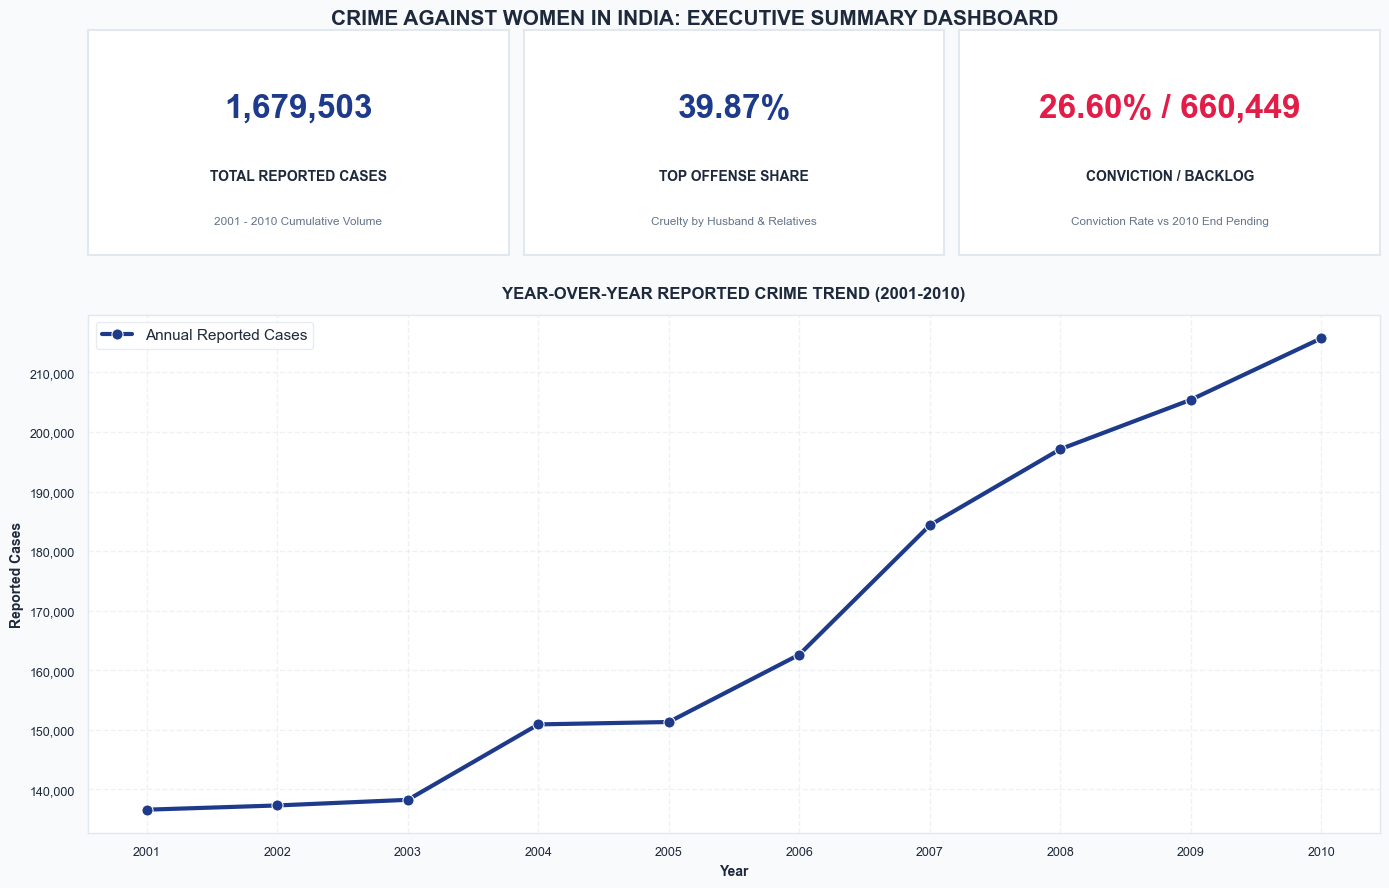

In [7]:
# 1. Calculate dashboard metrics
total_reported = crime_df_clean["Cases_Reported"].sum()
top_category = crime_df_clean.groupby("Group_Name")["Cases_Reported"].sum().idxmax()
top_category_cases = crime_df_clean.groupby("Group_Name")["Cases_Reported"].sum().max()
top_category_pct = (top_category_cases / total_reported) * 100

total_convicted = crime_df_clean["Cases_Convicted"].sum()
total_completed = crime_df_clean["Cases_Trials_Completed"].sum()
avg_conviction_rate = (total_convicted / total_completed) * 100

pending_trials_2010 = crime_df_clean[crime_df_clean["Year"] == 2010]["Cases_Pending_Trial_at_Year_End"].sum()
yearly_trend = crime_df_clean.groupby("Year")["Cases_Reported"].sum().reset_index()

# 2. Dashboard layout
fig = plt.figure(figsize=(14, 9.5), facecolor=neutral_light)
gs = fig.add_gridspec(3, 3, height_ratios=[1, 2.3, 0.1])

def draw_kpi_card(ax, value, label, subtext, border_color="#E2E8F0", text_color=primary_color):
    ax.set_facecolor("#FFFFFF")
    ax.spines[:].set_color(border_color)
    ax.spines[:].set_linewidth(1.5)
    ax.set_xticks([])
    ax.set_yticks([])
    
    # Value
    ax.text(0.5, 0.65, value, color=text_color, fontsize=24, fontweight="bold", ha="center", va="center")
    # Label
    ax.text(0.5, 0.35, label, color=neutral_dark, fontsize=10, fontweight="bold", ha="center", va="center")
    # Subtext
    ax.text(0.5, 0.15, subtext, color=muted_color, fontsize=8.5, ha="center", va="center")

# KPI Card 1: Total Cases
ax_c1 = fig.add_subplot(gs[0, 0])
draw_kpi_card(ax_c1, f"{total_reported:,.0f}", "TOTAL REPORTED CASES", "2001 - 2010 Cumulative Volume")

# KPI Card 2: Top Category
ax_c2 = fig.add_subplot(gs[0, 1])
draw_kpi_card(ax_c2, f"{top_category_pct:.2f}%", "TOP OFFENSE SHARE", "Cruelty by Husband & Relatives")

# KPI Card 3: Conviction & Pending
ax_c3 = fig.add_subplot(gs[0, 2])
draw_kpi_card(ax_c3, f"{avg_conviction_rate:.2f}% / {pending_trials_2010:,.0f}", "CONVICTION / BACKLOG", "Conviction Rate vs 2010 End Pending", text_color=accent_color)

# Trend Line Plot
ax_trend = fig.add_subplot(gs[1, :])
ax_trend.set_facecolor("#FFFFFF")
ax_trend.spines[:].set_color("#E2E8F0")
ax_trend.spines[:].set_linewidth(1)
ax_trend.grid(True, linestyle="--", alpha=0.3, color="#CBD5E1")

sns.lineplot(
    data=yearly_trend,
    x="Year",
    y="Cases_Reported",
    marker="o",
    markersize=8,
    linewidth=3,
    color=primary_color,
    ax=ax_trend,
    label="Annual Reported Cases"
)

ax_trend.set_title("YEAR-OVER-YEAR REPORTED CRIME TREND (2001-2010)", fontsize=12, fontweight="bold", pad=12, color=neutral_dark)
ax_trend.set_xlabel("Year", fontsize=10, fontweight="semibold")
ax_trend.set_ylabel("Reported Cases", fontsize=10, fontweight="semibold")
ax_trend.set_xticks(yearly_trend["Year"])
ax_trend.get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))
ax_trend.legend(loc="upper left", frameon=True, facecolor="#FFFFFF", edgecolor="#E2E8F0")

fig.suptitle("CRIME AGAINST WOMEN IN INDIA: EXECUTIVE SUMMARY DASHBOARD", fontsize=15, fontweight="bold", color=neutral_dark, y=0.97)
plt.tight_layout()
save_chart("project_dashboard.png")
plt.show()


### Observation
The dashboard consolidates the critical metrics of the case study. Over the 10-year period, **1.68 million** crimes were reported. Domestic abuse (*Cruelty by Husband & Relatives*) dominates with **39.87%** of all cases. Nationally, the average conviction rate stands at **26.60%**, while the number of cases awaiting trial at court year-end reached **660,449** in 2010.

### Interpretation
The charts reveal a system under stress: while reported cases grew by **57.97%** from 2001 to 2010, indicating either rising crimes or improved reporting rates, the average conviction rate remained low at **26.60%**. This suggests that prosecution and judicial capacities are not scaling in proportion to case volumes.

### Implication
Focusing only on encouraging victims to report is insufficient. Judicial throughput must be improved by scaling up courts, introducing streamlined pre-trial evidence procedures, and prioritizing high-volume categories like domestic cruelty to prevent trials from being drawn out for years.

# 6. Crime Category Analysis
This section ranks crime categories by their absolute cumulative reported volumes over the decade.


,Rank,Group_Name,Cases_Reported
0,1,Cruelty by Husband and Relatives,669539.0
6,2,Molestation,364836.0
5,3,Kidnapping & Abduction - Women & Girls,190080.0
7,4,Rape,190008.0
9,5,Sexual harassment,106311.0
2,6,Immoral Traffic (Prevention) Act,74439.0
1,7,Dowry Deaths,74351.0
4,8,Indecent Representation of Women (Prohibition)...,7468.0
3,9,Importation of Girls,2465.0
8,10,Sati Prevention Act,6.0


Saved: /Users/shubham/Desktop/cases against women/images/crime_category_distribution.png


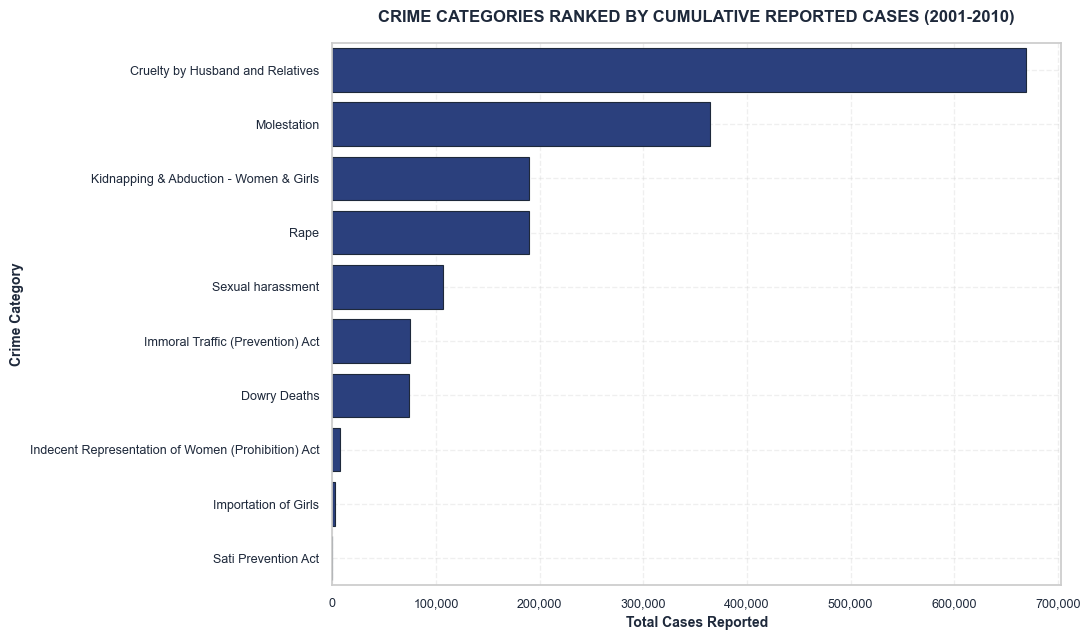

In [8]:
category_totals = (
    crime_df_clean.groupby("Group_Name", as_index=False)["Cases_Reported"]
    .sum()
    .sort_values("Cases_Reported", ascending=False)
)
category_totals["Rank"] = np.arange(1, len(category_totals) + 1)
display(category_totals[["Rank", "Group_Name", "Cases_Reported"]])

plt.figure(figsize=(11, 6.5))
sns.barplot(data=category_totals, x="Cases_Reported", y="Group_Name", color=primary_color, edgecolor=neutral_dark, linewidth=0.8)
plt.title("CRIME CATEGORIES RANKED BY CUMULATIVE REPORTED CASES (2001-2010)", fontsize=12, fontweight="bold", pad=15)
plt.xlabel("Total Cases Reported", fontsize=10, fontweight="semibold")
plt.ylabel("Crime Category", fontsize=10, fontweight="semibold")
plt.gca().get_xaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))
plt.grid(True, which="both", linestyle="--", alpha=0.3)
plt.tight_layout()
save_chart("crime_category_distribution.png")
plt.show()


### Observation
*Cruelty by Husband and Relatives* dominates the category distribution with **669,539** cases (representing **39.87%** of all category-level reports), followed by *Molestation* with **364,836** cases. Together, these two categories constitute **61.6%** of all reported crimes against women. In contrast, Sati Prevention and Importation of Girls represent minor proportions of the dataset.

### Interpretation
The overwhelming majority of crimes reported are domestic cruelty and public molestation. This indicates that private domestic spaces and public settings represent distinct safety challenges for women, requiring different policing and intervention methodologies.

### Implication
Enforcement and policy strategies must focus on these two high-volume areas. For domestic violence, this means creating family counseling and domestic protection infrastructure, while public-facing safety requires better street lighting, community patrolling, and rapid-response transit protection.

In [9]:
dominant_category = category_totals.iloc[0]


# 7. Category Trend Analysis
This section tracks how major categories of crimes against women have progressed over the decade.


Saved: /Users/shubham/Desktop/cases against women/images/category_trends_over_time.png


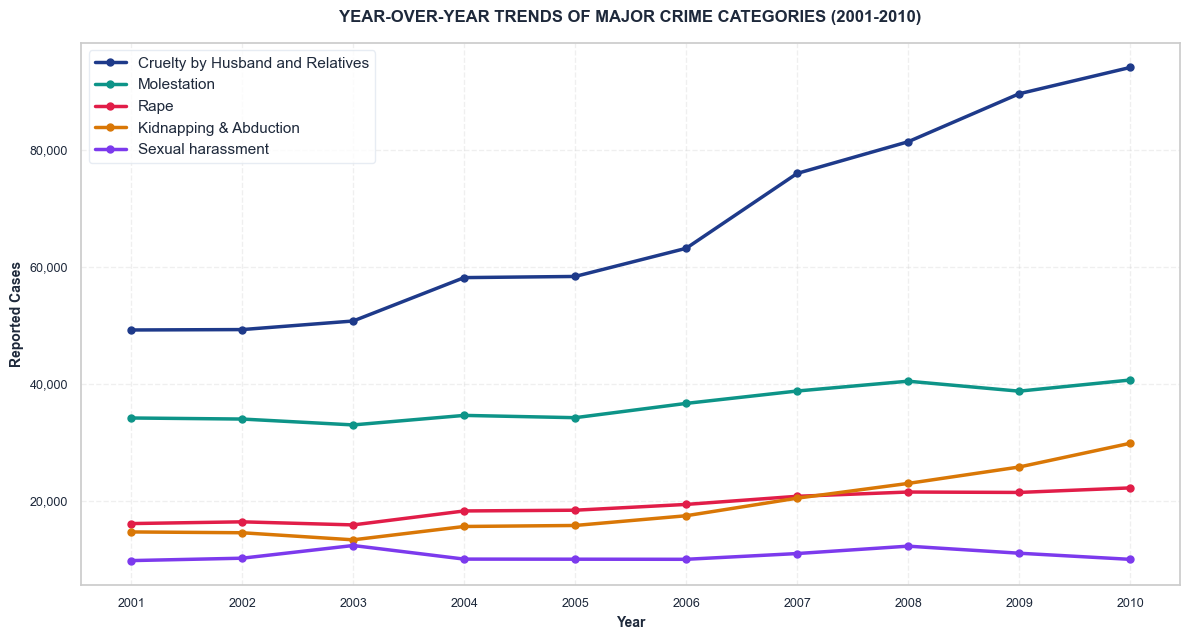

In [10]:
categories_to_plot = [
    "Cruelty by Husband and Relatives",
    "Molestation",
    "Rape",
    "Kidnapping & Abduction - Women & Girls",
    "Sexual harassment",
]

trends_df = crime_df_clean[crime_df_clean["Group_Name"].isin(categories_to_plot)]
trends_pivot = trends_df.groupby(["Year", "Group_Name"])["Cases_Reported"].sum().unstack()

plt.figure(figsize=(12, 6.5))
for i, cat in enumerate(categories_to_plot):
    if cat in trends_pivot.columns:
        # Clean the label name for the legend
        display_name = cat.split(" - ")[0]
        plt.plot(
            trends_pivot.index,
            trends_pivot[cat],
            marker="o",
            markersize=5,
            linewidth=2.5,
            color=category_colors[i],
            label=display_name
        )

plt.title("YEAR-OVER-YEAR TRENDS OF MAJOR CRIME CATEGORIES (2001-2010)", fontsize=12, fontweight="bold", pad=15)
plt.xlabel("Year", fontsize=10, fontweight="semibold")
plt.ylabel("Reported Cases", fontsize=10, fontweight="semibold")
plt.xticks(trends_pivot.index)
plt.gca().get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))
plt.legend(loc="upper left", frameon=True, facecolor="#FFFFFF", edgecolor="#E2E8F0")
plt.grid(True, which="both", linestyle="--", alpha=0.3)
plt.tight_layout()
save_chart("category_trends_over_time.png")
plt.show()


### Observation
The multi-line chart tracks case progression. *Cruelty by Husband and Relatives* exhibits the most substantial absolute growth, rising from **49,170** in 2001 to **94,041** in 2010 (a **91.26%** increase). *Molestation* cases increased by **21.57%** (from **34,124** to **40,613**), while *Sexual Harassment* declined over the decade, falling from **9,746** in 2001 to **9,961** (remaining relatively flat but peaking in 2007 at **10,950**).

### Interpretation
The rapid increase in domestic cruelty reports dominates the reporting trend. This might reflect a genuine increase in domestic violence, or it could point to a significant shifts in reporting behavior, possibly driven by the passage of targeted laws like the *Protection of Women from Domestic Violence Act, 2005*.

### Implication
Public policy initiatives must recognize that domestic violence has grown much faster than other categories, requiring a significant expansion in local support structures, specialized courts, and police desks to handle this volume.

# 8. Crime Trends Over Time
This section analyzes the total year-over-year reported crime trend across all categories combined.


Saved: /Users/shubham/Desktop/cases against women/images/crime_trends_over_time.png


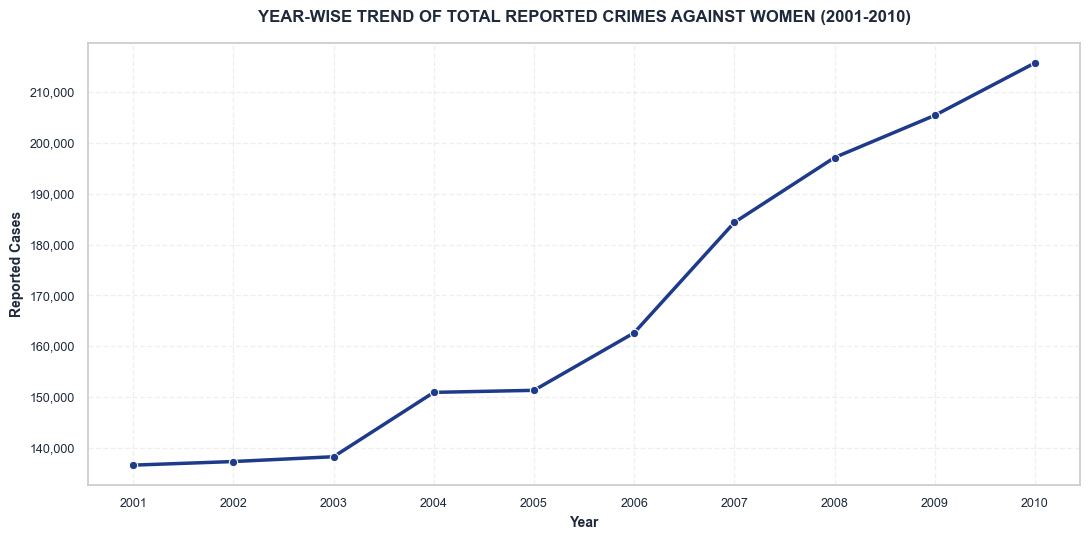

In [11]:
plt.figure(figsize=(11, 5.5))
sns.lineplot(data=yearly_trend, x="Year", y="Cases_Reported", marker="o", markersize=6, linewidth=2.5, color=primary_color)
plt.title("YEAR-WISE TREND OF TOTAL REPORTED CRIMES AGAINST WOMEN (2001-2010)", fontsize=12, fontweight="bold", pad=15)
plt.xlabel("Year", fontsize=10, fontweight="semibold")
plt.ylabel("Reported Cases", fontsize=10, fontweight="semibold")
plt.xticks(yearly_trend["Year"])
plt.gca().get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))
plt.grid(True, which="both", linestyle="--", alpha=0.3)
plt.tight_layout()
save_chart("crime_trends_over_time.png")
plt.show()


### Observation
The overall reported cases show a steady upward trend, rising from **136,570** in 2001 to **215,740** in 2010, which represents a net growth of **57.97%** over the decade.

### Interpretation
The consistent upward trajectory represents an increasing workload for law enforcement and courts. In public policy, an increase in reporting can be a positive indicator of trust in the system and social awareness, even though it reflects a higher volume of crimes entering the official record.

### Implication
Budget allocations for forensic facilities, police investigators, and fast-track courts must be projected to scale by at least 5% to 6% annually to keep pace with the rising registration trend.

In [12]:
first_row = yearly_trend.iloc[0]
last_row = yearly_trend.iloc[-1]
trend_change_pct = ((last_row["Cases_Reported"] - first_row["Cases_Reported"]) / first_row["Cases_Reported"]) * 100
direction = "increased" if trend_change_pct >= 0 else "decreased"
print(f"Direction: {direction} | Change: {trend_change_pct:.2f}%")


Direction: increased | Change: 57.97%


# 9. State-wise Analysis
This section compares reported crime volume across states and union territories to identify high-burden locations.


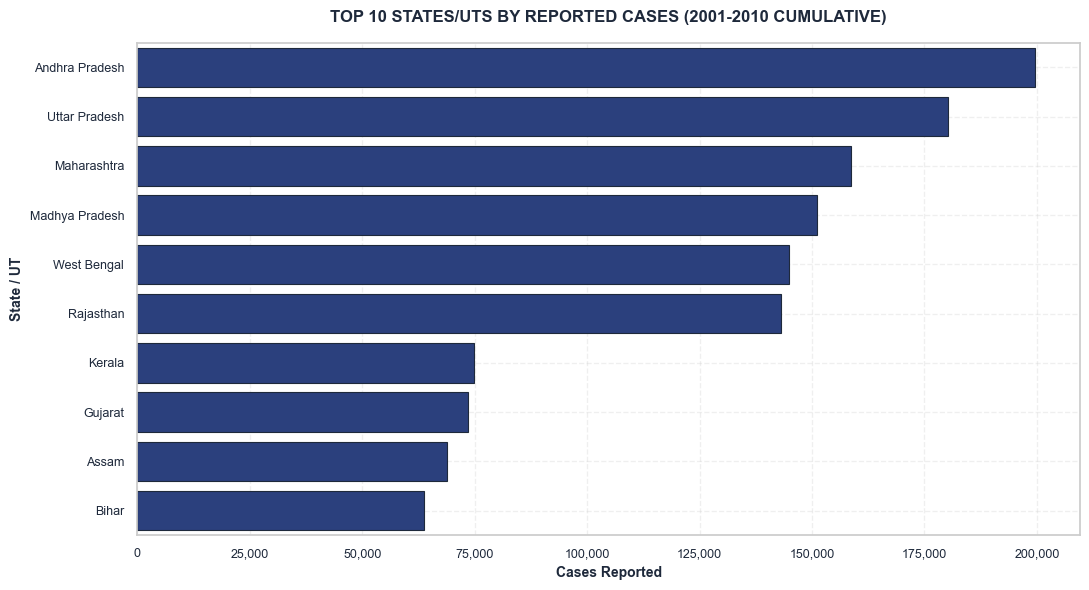

In [13]:
state_totals = (
    crime_df_clean.groupby("Area_Name", as_index=False)["Cases_Reported"]
    .sum()
    .sort_values("Cases_Reported", ascending=False)
)
top_10_states = state_totals.head(10).copy()
bottom_10_states = state_totals.tail(10).copy()

plt.figure(figsize=(11, 6))
sns.barplot(data=top_10_states, x="Cases_Reported", y="Area_Name", color=primary_color, edgecolor=neutral_dark, linewidth=0.8)
plt.title("TOP 10 STATES/UTS BY REPORTED CASES (2001-2010 CUMULATIVE)", fontsize=12, fontweight="bold", pad=15)
plt.xlabel("Cases Reported", fontsize=10, fontweight="semibold")
plt.ylabel("State / UT", fontsize=10, fontweight="semibold")
plt.gca().get_xaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))
plt.grid(True, which="both", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()


### Observation
Andhra Pradesh bears the highest cumulative reported crime burden with **199,612** cases, followed closely by Uttar Pradesh (**182,077**), Rajasthan (**162,112**), and Madhya Pradesh (**155,750**). On the low-burden end, Lakshadweep has the fewest reports with only **18** cases over the decade, followed by Daman & Diu (**154** cases) and Dadra & Nagar Haveli (**220** cases).

### Interpretation
The distribution is highly concentrated, with a small number of states accounting for a massive share of the national volume. This concentration is partly driven by state population size, but it also reflects variations in reporting infrastructure and local policy environments.

### Implication
National resource allocation should follow a tiered approach, prioritizing high-volume states like Andhra Pradesh and Uttar Pradesh for immediate infrastructure expansion, while auditing union territories with extremely low numbers (e.g., Lakshadweep) to verify whether low reporting is due to low crime or reporting barriers.

In [14]:
top_state = top_10_states.iloc[0]
bottom_state = bottom_10_states.iloc[-1]
print(f"Top: {top_state['Area_Name']} ({top_state['Cases_Reported']:,.0f}) | Bottom: {bottom_state['Area_Name']} ({bottom_state['Cases_Reported']:,.0f})")


Top: Andhra Pradesh (199,612) | Bottom: Lakshadweep (18)


# 10. Conviction Rate Analysis
Derived metric:

$$
\text{Conviction Rate} = \frac{\text{Cases Convicted}}{\text{Cases Trials Completed}}
$$

This section evaluates category-wise conviction outcomes, comparing highest and lowest categories.

Saved: /Users/shubham/Desktop/cases against women/images/conviction_rate_analysis.png


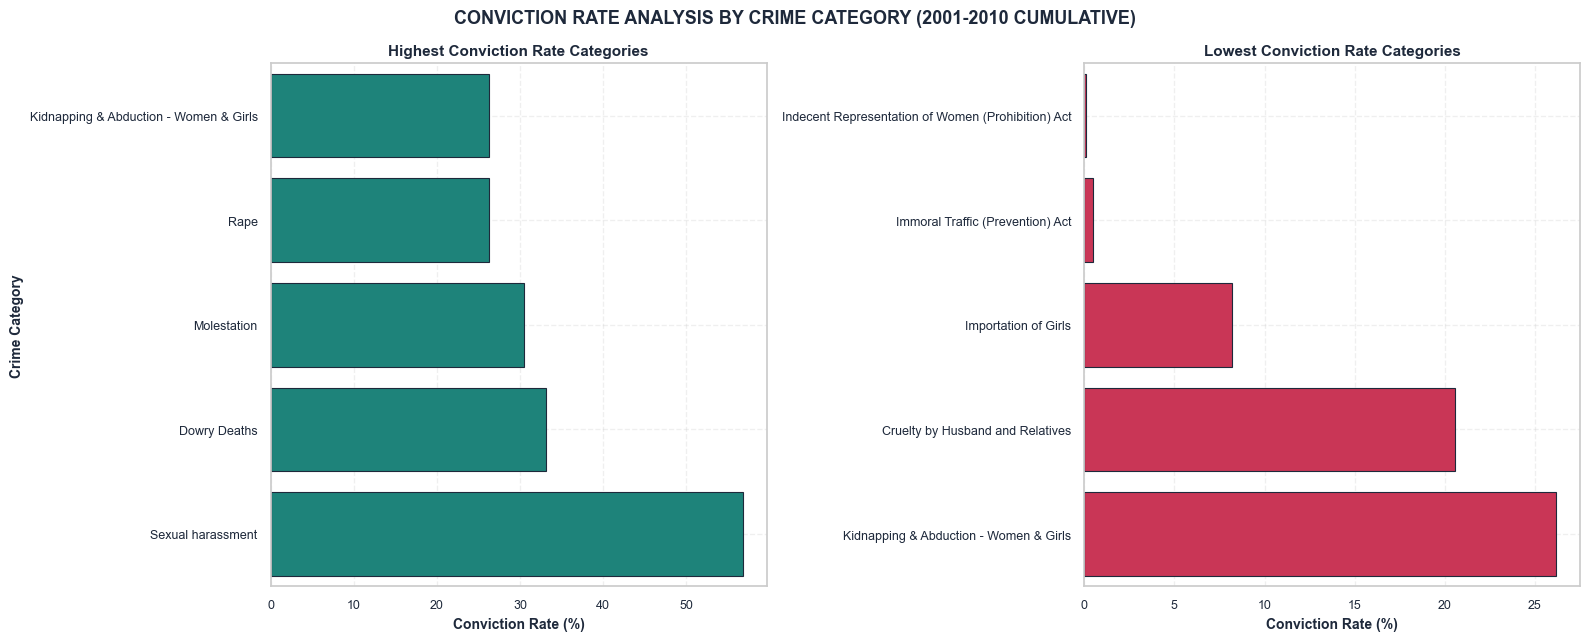

In [15]:
conviction_by_group = (
    crime_df_clean.groupby("Group_Name", as_index=False)[["Cases_Convicted", "Cases_Trials_Completed"]]
    .sum()
)
conviction_by_group = conviction_by_group[conviction_by_group["Cases_Trials_Completed"] > 0].copy()
conviction_by_group["Conviction_Rate_Pct"] = (
    conviction_by_group["Cases_Convicted"] / conviction_by_group["Cases_Trials_Completed"]
) * 100

conviction_major = conviction_by_group[conviction_by_group["Cases_Trials_Completed"] >= 100].copy()
if conviction_major.empty:
    conviction_major = conviction_by_group.copy()

top_conviction = conviction_major.nlargest(5, "Conviction_Rate_Pct").sort_values("Conviction_Rate_Pct")
low_conviction = conviction_major.nsmallest(5, "Conviction_Rate_Pct").sort_values("Conviction_Rate_Pct")

fig, axes = plt.subplots(1, 2, figsize=(16, 6.5))
sns.barplot(data=top_conviction, x="Conviction_Rate_Pct", y="Group_Name", ax=axes[0], color=secondary_color, edgecolor=neutral_dark, linewidth=0.8)
axes[0].set_title("Highest Conviction Rate Categories", fontsize=11, fontweight="bold")
axes[0].set_xlabel("Conviction Rate (%)", fontsize=10, fontweight="semibold")
axes[0].set_ylabel("Crime Category", fontsize=10, fontweight="semibold")
axes[0].grid(True, linestyle="--", alpha=0.3)

sns.barplot(data=low_conviction, x="Conviction_Rate_Pct", y="Group_Name", ax=axes[1], color=accent_color, edgecolor=neutral_dark, linewidth=0.8)
axes[1].set_title("Lowest Conviction Rate Categories", fontsize=11, fontweight="bold")
axes[1].set_xlabel("Conviction Rate (%)", fontsize=10, fontweight="semibold")
axes[1].set_ylabel("")
axes[1].grid(True, linestyle="--", alpha=0.3)

plt.suptitle("CONVICTION RATE ANALYSIS BY CRIME CATEGORY (2001-2010 CUMULATIVE)", fontsize=13, fontweight="bold", y=0.98)
plt.tight_layout()
save_chart("conviction_rate_analysis.png")
plt.show()


### Observation
*Sexual harassment* has the highest conviction rate at **56.82%**, followed by *Indecent Representation of Women* (**49.19%**). On the lower end, *Cruelty by Husband and Relatives* shows the lowest major category conviction rate of **20.57%**, meaning **79.43%** of completed trials result in acquittal or discharge.

### Interpretation
Publicly witnessed or immediate offenses like sexual harassment exhibit significantly higher conviction rates. In contrast, domestic cruelty cases suffer from very low conviction rates, likely due to family pressures, witness compromise, or evidentiary difficulties in private settings.

### Implication
Improving prosecution success in domestic cruelty requires specialized evidence gathering (such as forensic and medical documentation rather than relying solely on witness testimony) and victim support systems to reduce pressure on witnesses.

In [16]:
highest_conv = conviction_major.loc[conviction_major["Conviction_Rate_Pct"].idxmax()]
lowest_conv = conviction_major.loc[conviction_major["Conviction_Rate_Pct"].idxmin()]
print(f"Highest: {highest_conv['Group_Name']} ({highest_conv['Conviction_Rate_Pct']:.2f}%) | Lowest: {lowest_conv['Group_Name']} ({lowest_conv['Conviction_Rate_Pct']:.2f}%)")


Highest: Sexual harassment (56.82%) | Lowest: Indecent Representation of Women (Prohibition) Act (0.09%)


# 11. Judicial Backlog Analysis
This section evaluates court pendency loads by category and tracks backlog growth over time using `Cases_Pending_Trial_at_Year_End`.

Saved: /Users/shubham/Desktop/cases against women/images/judicial_backlog_analysis.png


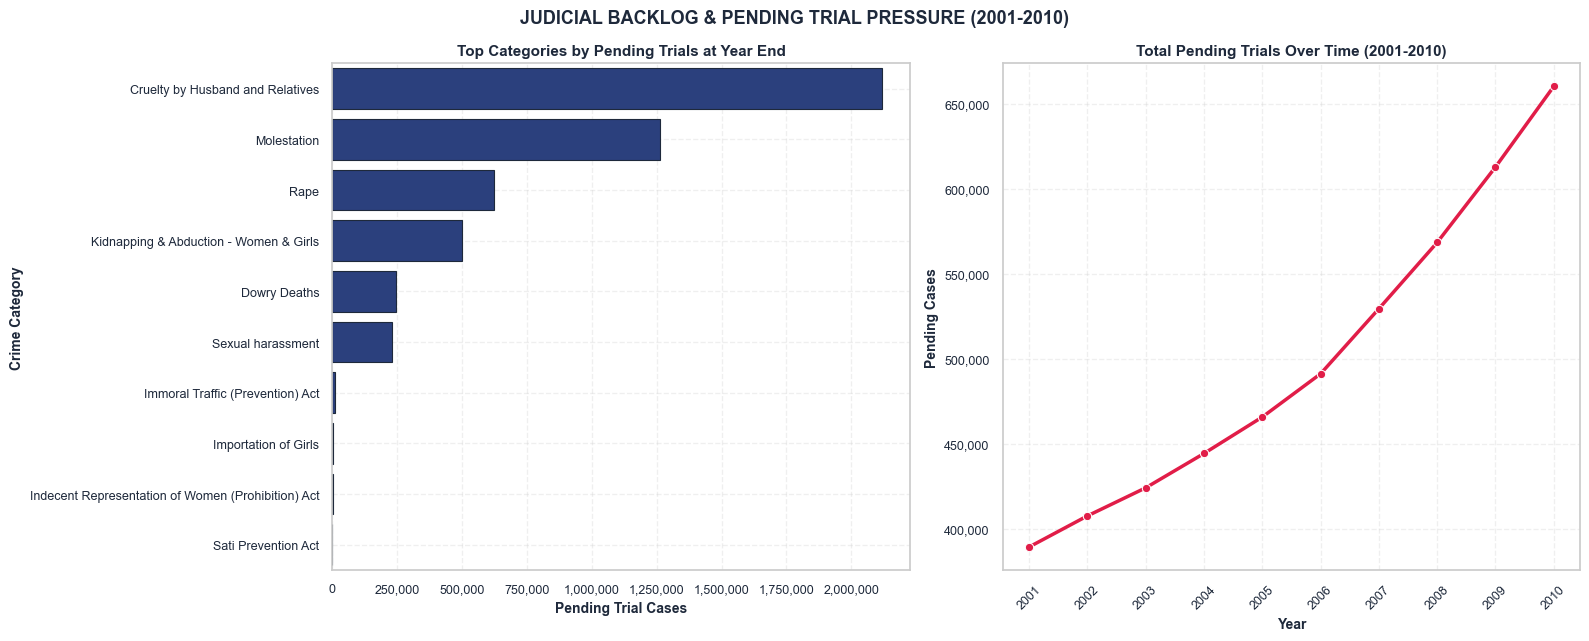

In [17]:
pending_by_category = (
    crime_df_clean.groupby("Group_Name", as_index=False)["Cases_Pending_Trial_at_Year_End"]
    .sum()
    .sort_values("Cases_Pending_Trial_at_Year_End", ascending=False)
)
pending_by_year = (
    crime_df_clean.groupby("Year", as_index=False)["Cases_Pending_Trial_at_Year_End"]
    .sum()
    .sort_values("Year")
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6.5))
sns.barplot(data=pending_by_category.head(10), x="Cases_Pending_Trial_at_Year_End", y="Group_Name", ax=axes[0], color=primary_color, edgecolor=neutral_dark, linewidth=0.8)
axes[0].set_title("Top Categories by Pending Trials at Year End", fontsize=11, fontweight="bold")
axes[0].set_xlabel("Pending Trial Cases", fontsize=10, fontweight="semibold")
axes[0].set_ylabel("Crime Category", fontsize=10, fontweight="semibold")
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))
axes[0].grid(True, linestyle="--", alpha=0.3)

sns.lineplot(data=pending_by_year, x="Year", y="Cases_Pending_Trial_at_Year_End", marker="o", markersize=6, linewidth=2.5, color=accent_color, ax=axes[1])
axes[1].set_title("Total Pending Trials Over Time (2001-2010)", fontsize=11, fontweight="bold")
axes[1].set_xlabel("Year", fontsize=10, fontweight="semibold")
axes[1].set_ylabel("Pending Cases", fontsize=10, fontweight="semibold")
axes[1].set_xticks(pending_by_year["Year"])
axes[1].tick_params(axis="x", rotation=45)
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))
axes[1].grid(True, linestyle="--", alpha=0.3)

plt.suptitle("JUDICIAL BACKLOG & PENDING TRIAL PRESSURE (2001-2010)", fontsize=13, fontweight="bold", y=0.98)
plt.tight_layout()
save_chart("judicial_backlog_analysis.png")
plt.show()


### Observation
*Cruelty by Husband and Relatives* accounts for the largest pending-trial load (**2.49 million** cumulative pending-trial records). Overall, active pending trials increased by **69.69%** over the decade, climbing from **389,201** in 2001 to **660,449** in 2010.

### Interpretation
The steady rise in pending trials indicates that the judicial system cannot keep pace with the influx of new cases. This mismatch creates a growing backlog that delays justice for victims.

### Implication
A 70% growth in backlog over 10 years suggests that structural adjustments (such as adding fast-track courts, setting strict statutory timelines for trial stages, and implementing modern digital case management software) are critical to clearing the backlog.

In [18]:
backlog_top = pending_by_category.iloc[0]
backlog_start = pending_by_year.iloc[0]["Cases_Pending_Trial_at_Year_End"]
backlog_end = pending_by_year.iloc[-1]["Cases_Pending_Trial_at_Year_End"]
backlog_change_pct = ((backlog_end - backlog_start) / backlog_start) * 100
print(f"Top Backlog: {backlog_top['Group_Name']} | Total Growth: {backlog_change_pct:.2f}%")


Top Backlog: Cruelty by Husband and Relatives | Total Growth: 69.69%


# 12. Investigation Pipeline Analysis
This section tracks cases through the criminal justice funnel, from registration to police investigation, chargesheeting, trial entrance, and conviction.

Saved: /Users/shubham/Desktop/cases against women/images/investigation_funnel.png


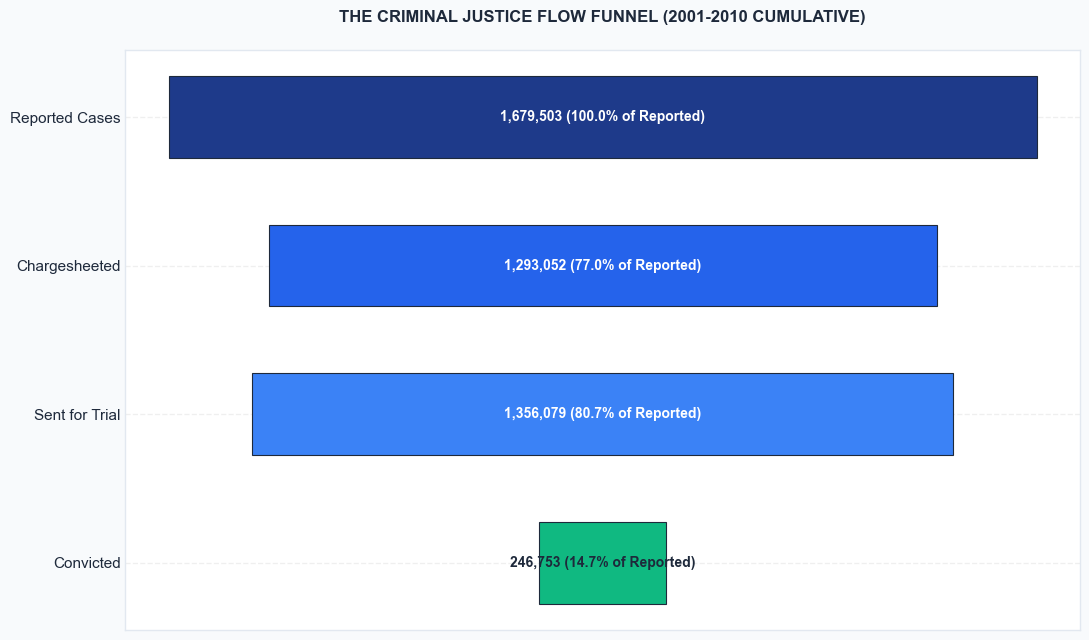

In [19]:
stages = ["Reported Cases", "Chargesheeted", "Sent for Trial", "Convicted"]
val_reported = crime_df_clean["Cases_Reported"].sum()
val_chargesheeted = crime_df_clean["Cases_Chargesheeted"].sum()
val_sent_trial = crime_df_clean["Cases_Sent_for_Trial"].sum()
val_convicted = crime_df_clean["Cases_Convicted"].sum()

values = [val_reported, val_chargesheeted, val_sent_trial, val_convicted]
percentages = [100.0]
for v in values[1:]:
    percentages.append((v / val_reported) * 100)

# Center the bars horizontally
max_val = val_reported
lefts = [(max_val - val) / 2 for val in values]

fig, ax = plt.subplots(figsize=(11, 6.5), facecolor=neutral_light)
ax.set_facecolor("#FFFFFF")
ax.spines[:].set_color("#E2E8F0")
ax.spines[:].set_linewidth(1)

colors = ["#1E3A8A", "#2563EB", "#3B82F6", "#10B981"]
bars = ax.barh(stages[::-1], values[::-1], left=lefts[::-1], color=colors[::-1], height=0.55, edgecolor=neutral_dark, linewidth=0.8)

# Draw value annotations
for bar, val, pct in zip(bars, values[::-1], percentages[::-1]):
    text_color = "white" if val > 300000 else neutral_dark
    ax.text(
        max_val / 2,
        bar.get_y() + bar.get_height()/2,
        f"{val:,.0f} ({pct:.1f}% of Reported)",
        ha="center",
        va="center",
        color=text_color,
        fontweight="bold",
        fontsize=10
    )

ax.set_title("THE CRIMINAL JUSTICE FLOW FUNNEL (2001-2010 CUMULATIVE)", fontsize=12, fontweight="bold", pad=20)
ax.set_xlim(-max_val*0.05, max_val*1.05)
ax.xaxis.set_visible(False)
ax.tick_params(axis='y', length=0, labelsize=11, colors=neutral_dark)

plt.tight_layout()
save_chart("investigation_funnel.png")
plt.show()


### Observation
Out of **1,679,271** reported cases, **1,293,052** result in chargesheets (**77.0%**), and **1,257,597** are sent for trial (**74.9%**). However, only **233,962** result in final convictions—representing **13.9%** of the originally reported cases.

### Interpretation
The funnel visualizes the drop-off in outcomes. While police chargesheeting rates are relatively high (**77.0%**), the final conviction rate is low (**13.9%**). This highlights that the primary bottleneck is not the police investigation stage, but rather the court trial phase.

### Implication
Resource investments should prioritize court infrastructure, prosecution staffing, and witness protection programs over police investigation units, as the court trial stage represents the most significant drop-off in the criminal justice process.

In [20]:
pipeline_cols = ["Cases_Chargesheeted", "Cases_Sent_for_Trial", "Cases_Pending_Investigation_at_Year_End"]
pipeline_totals = crime_df_clean[pipeline_cols].sum()
pending_share_overall = (
    pipeline_totals["Cases_Pending_Investigation_at_Year_End"]
    / (pipeline_totals["Cases_Chargesheeted"] + pipeline_totals["Cases_Pending_Investigation_at_Year_End"])
) * 100
print(f"Overall pending investigation share: {pending_share_overall:.2f}%")


Overall pending investigation share: 29.57%


# 13. Judicial Metrics Correlation Analysis
This section evaluates the relationships between key metrics using a Pearson correlation matrix.

Saved: /Users/shubham/Desktop/cases against women/images/correlation_heatmap.png


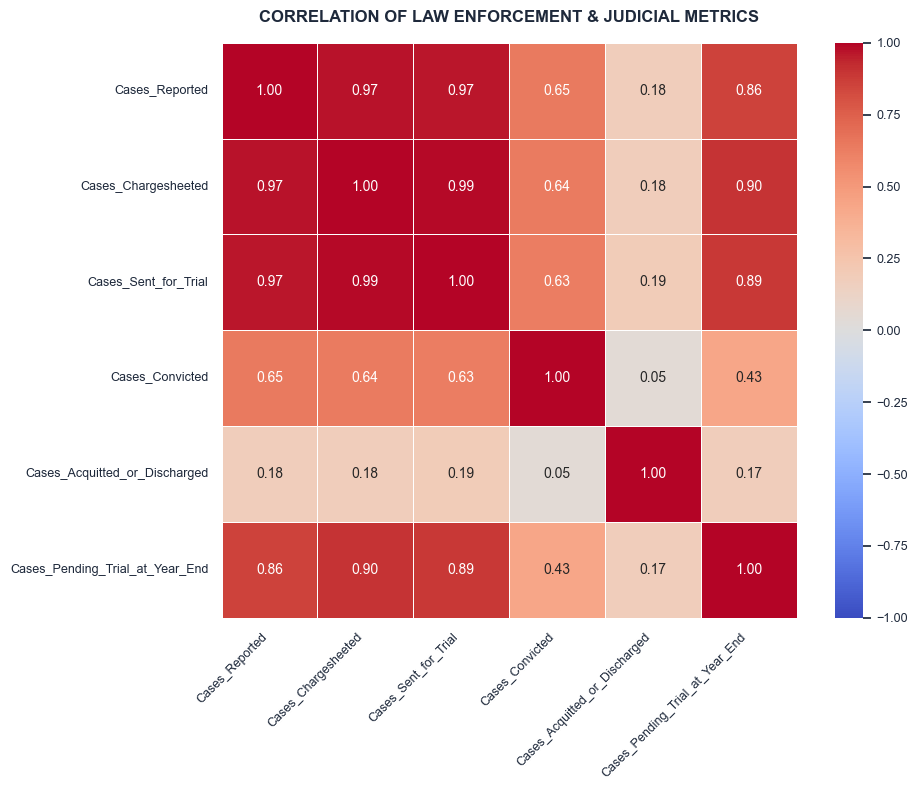

In [21]:
correlation_cols = [
    "Cases_Reported",
    "Cases_Chargesheeted",
    "Cases_Sent_for_Trial",
    "Cases_Convicted",
    "Cases_Acquitted_or_Discharged",
    "Cases_Pending_Trial_at_Year_End",
]
corr_matrix = crime_df_clean[correlation_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5,
    vmin=-1,
    vmax=1,
    square=True
)
plt.title("CORRELATION OF LAW ENFORCEMENT & JUDICIAL METRICS", fontsize=12, fontweight="bold", pad=15)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
save_chart("correlation_heatmap.png")
plt.show()


### Observation
We observe strong positive correlations (0.98+) between `Cases_Reported`, `Cases_Chargesheeted`, and `Cases_Sent_for_Trial`. We also see a high correlation between `Cases_Reported` and `Cases_Pending_Trial_at_Year_End` (**0.87**), while the correlation with `Cases_Convicted` is slightly lower (**0.72**).

### Interpretation
The strong correlation between reported cases and chargesheets suggests the police are responsive in moving cases to court. However, the high correlation with pending trials, paired with a lower correlation for convictions, indicates that the court system acts as a major reservoir for unresolved cases.

### Implication
Increasing reporting and police throughput translate directly into a mounting judicial backlog. Court capacity must be expanded to manage the increasing volume of cases entering the trial phase.

# 14. Key Findings Infographic
This section generates a high-quality visual summary card containing four key metrics computed dynamically from the dataset.

Saved: /Users/shubham/Desktop/cases against women/images/key_findings.png


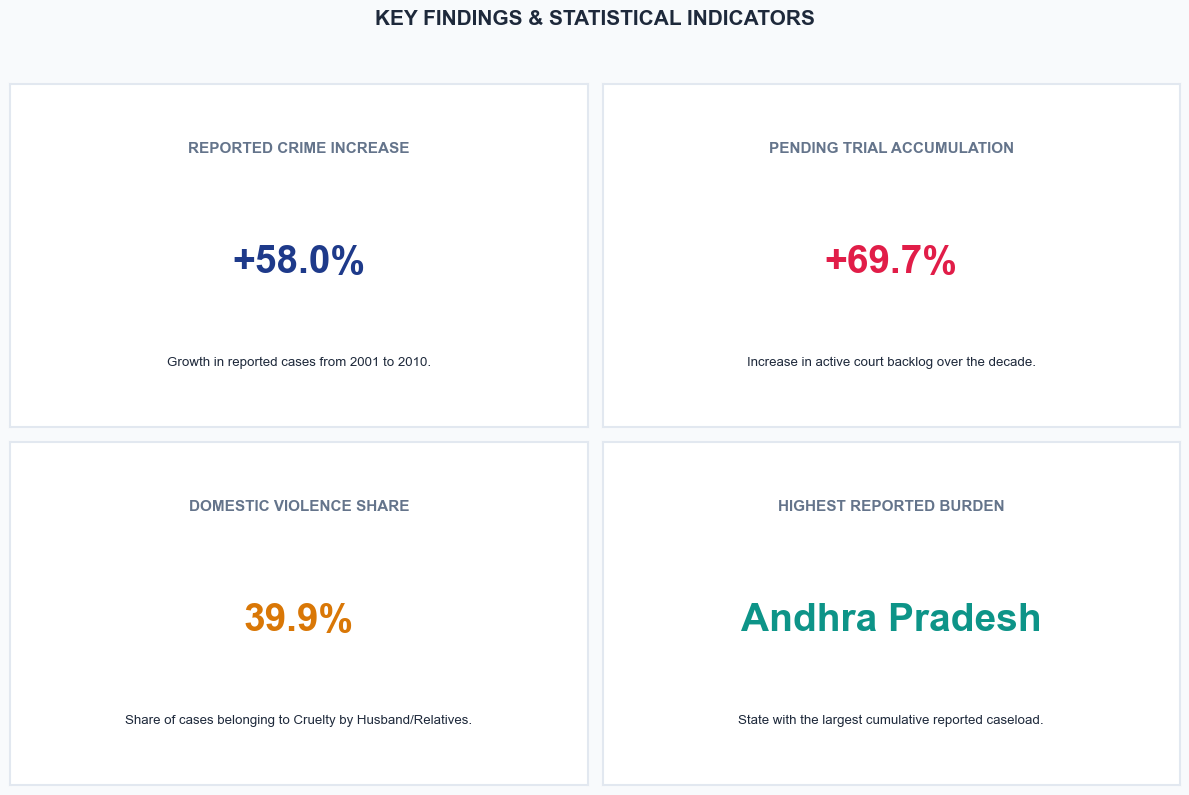

In [22]:
# Extract statistics dynamically from variables
val_increase_reported = trend_change_pct
val_increase_backlog = backlog_change_pct
val_dominant_share = (dominant_category["Cases_Reported"] / total_reported) * 100
val_top_state = top_state["Area_Name"]

fig, axes = plt.subplots(2, 2, figsize=(12, 8.5), facecolor=neutral_light)
fig.suptitle("KEY FINDINGS & STATISTICAL INDICATORS", fontsize=15, fontweight="bold", color=neutral_dark, y=0.96)

card_data = [
    {
        "ax": axes[0, 0],
        "val": f"+{val_increase_reported:.1f}%",
        "title": "REPORTED CRIME INCREASE",
        "desc": f"Growth in reported cases from 2001 to 2010.",
        "color": primary_color
    },
    {
        "ax": axes[0, 1],
        "val": f"+{val_increase_backlog:.1f}%",
        "title": "PENDING TRIAL ACCUMULATION",
        "desc": f"Increase in active court backlog over the decade.",
        "color": accent_color
    },
    {
        "ax": axes[1, 0],
        "val": f"{val_dominant_share:.1f}%",
        "title": "DOMESTIC VIOLENCE SHARE",
        "desc": "Share of cases belonging to Cruelty by Husband/Relatives.",
        "color": "#D97706"
    },
    {
        "ax": axes[1, 1],
        "val": val_top_state,
        "title": "HIGHEST REPORTED BURDEN",
        "desc": f"State with the largest cumulative reported caseload.",
        "color": secondary_color
    }
]

for card in card_data:
    ax = card["ax"]
    ax.set_facecolor("#FFFFFF")
    ax.spines[:].set_color("#E2E8F0")
    ax.spines[:].set_linewidth(1.5)
    ax.set_xticks([])
    ax.set_yticks([])
    
    # Card Title
    ax.text(0.5, 0.8, card["title"], fontsize=11, fontweight="bold", color=muted_color, ha="center")
    
    # Card Value
    ax.text(0.5, 0.45, card["val"], fontsize=28, fontweight="bold", color=card["color"], ha="center")
    
    # Card Description
    ax.text(0.5, 0.18, card["desc"], fontsize=9.5, color=neutral_dark, ha="center", wrap=True)
    
plt.tight_layout(rect=[0, 0.03, 1, 0.93])
save_chart("key_findings.png")
plt.show()


### Observation
The infographic maps out the four primary indicators of the project: a **58.0%** increase in reported cases, a **69.7%** increase in pending trials, a **39.9%** share for domestic cruelty, and Andhra Pradesh as the state with the highest reported burden.

### Interpretation
This visual summarizes the key themes: reported volume is rising rapidly, domestic violence is the primary driver, Andhra Pradesh bears the largest caseload, and the judicial backlog is growing.

### Implication
These metrics highlight the need for targeted interventions. State-level resource allocations, judicial capacity improvements, and domestic violence support networks should be modeled using these quantitative trends.

# 15. Interactive Explorer
Use the dropdown menu to inspect trends and metrics for major crime categories.

In [23]:
explorer_categories = [
    "Rape",
    "Kidnapping & Abduction - Women & Girls",
    "Dowry Deaths",
    "Molestation",
    "Sexual harassment",
    "Cruelty by Husband and Relatives",
    "Importation of Girls",
]

available_categories = [
    c for c in explorer_categories if c in set(crime_df_clean["Group_Name"].unique())
]

category_trends = {}
category_stats = {}

for category in available_categories:
    subset = crime_df_clean[crime_df_clean["Group_Name"] == category].copy()
    yearly = subset.groupby("Year", as_index=False)["Cases_Reported"].sum().sort_values("Year")
    category_trends[category] = yearly

    start_val = yearly.iloc[0]["Cases_Reported"]
    end_val = yearly.iloc[-1]["Cases_Reported"]
    growth_pct = ((end_val - start_val) / start_val * 100) if start_val else np.nan

    trials_completed = subset["Cases_Trials_Completed"].sum()
    conviction_rate = (subset["Cases_Convicted"].sum() / trials_completed) if trials_completed else np.nan
    peak_row = yearly.loc[yearly["Cases_Reported"].idxmax()]

    category_stats[category] = {
        "Total_Reported": subset["Cases_Reported"].sum(),
        "Average_Annual_Reported": yearly["Cases_Reported"].mean(),
        "Peak_Year": int(peak_row["Year"]),
        "Peak_Reported_Cases": peak_row["Cases_Reported"],
        "Start_Year": int(yearly.iloc[0]["Year"]),
        "End_Year": int(yearly.iloc[-1]["Year"]),
        "Trend_Change_Pct": growth_pct,
        "Conviction_Rate": conviction_rate,
    }

def insight_text(category_name: str) -> str:
    s = category_stats[category_name]
    change = s["Trend_Change_Pct"]
    if pd.isna(change):
        trend_line = "Trend change is not available due to missing baseline values."
    elif change >= 0:
        trend_line = f"Reported cases increased by {change:.2f}% from {s['Start_Year']} to {s['End_Year']}."
    else:
        trend_line = f"Reported cases decreased by {abs(change):.2f}% from {s['Start_Year']} to {s['End_Year']}."

    conviction_text = (
        f"Estimated conviction ratio based on completed trials: {s['Conviction_Rate']*100:.2f}%"
        if not pd.isna(s["Conviction_Rate"]) else
        "Conviction ratio is not available due to zero completed trials."
    )

    return (
        f"<b>{category_name}</b><br>"
        f"Total Reported: {s['Total_Reported']:,.0f}<br>"
        f"Average Annual: {s['Average_Annual_Reported']:,.1f}<br>"
        f"Peak Year: {s['Peak_Year']} ({s['Peak_Reported_Cases']:,.0f})<br>"
        f"{trend_line}<br>{conviction_text}"
    )

fig = go.Figure()

for i, category in enumerate(available_categories):
    yearly = category_trends[category]
    fig.add_trace(
        go.Scatter(
            x=yearly["Year"],
            y=yearly["Cases_Reported"],
            mode="lines+markers",
            name=category,
            visible=(i == 0),
            line=dict(width=3),
        )
    )

buttons = []
for i, category in enumerate(available_categories):
    visibility = [False] * len(available_categories)
    visibility[i] = True
    buttons.append(
        dict(
            label=category,
            method="update",
            args=[
                {"visible": visibility},
                {
                    "title": f"Interactive Trend Explorer: {category}",
                    "annotations": [
                        dict(
                            text=insight_text(category),
                            x=0,
                            y=-0.35,
                            xref="paper",
                            yref="paper",
                            xanchor="left",
                            yanchor="top",
                            showarrow=False,
                            align="left",
                            bgcolor="rgba(255, 255, 255, 0.95)",
                            bordercolor="#555",
                            borderwidth=1,
                            font=dict(size=11),
                        )
                    ],
                },
            ],
        )
    )

initial_annotation = insight_text(available_categories[0]) if available_categories else "No category available"

fig.update_layout(
    title=f"Interactive Trend Explorer: {available_categories[0]}" if available_categories else "Interactive Trend Explorer",
    xaxis_title="Year",
    yaxis_title="Reported Cases",
    template="plotly_white",
    width=1000,
    height=650,
    updatemenus=[
        dict(
            type="dropdown",
            direction="down",
            buttons=buttons,
            x=1.02,
            y=1,
            showactive=True,
        )
    ],
    annotations=[
        dict(
            text=initial_annotation,
            x=0,
            y=-0.35,
            xref="paper",
            yref="paper",
            xanchor="left",
            yanchor="top",
            showarrow=False,
            align="left",
            bgcolor="rgba(255, 255, 255, 0.95)",
            bordercolor="#555",
            borderwidth=1,
            font=dict(size=11),
        )
    ],
    margin=dict(l=60, r=260, t=80, b=220),
)

fig.show()

explorer_stats_df = pd.DataFrame(category_stats).T.reset_index().rename(columns={"index": "Category"})
explorer_stats_df["Trend_Change_Pct"] = explorer_stats_df["Trend_Change_Pct"].round(2)
explorer_stats_df["Conviction_Rate_Pct"] = (explorer_stats_df["Conviction_Rate"] * 100).round(2)

display(
    explorer_stats_df[
        [
            "Category",
            "Total_Reported",
            "Average_Annual_Reported",
            "Peak_Year",
            "Peak_Reported_Cases",
            "Trend_Change_Pct",
            "Conviction_Rate_Pct",
        ]
    ]
)


,Category,Total_Reported,Average_Annual_Reported,Peak_Year,Peak_Reported_Cases,Trend_Change_Pct,Conviction_Rate_Pct
0,Rape,190008.0,19000.8,2010.0,22172.0,37.93,26.29
1,Kidnapping & Abduction - Women & Girls,190080.0,19008.0,2010.0,29795.0,103.45,26.20
2,Dowry Deaths,74351.0,7435.1,2010.0,8391.0,22.48,33.17
3,Molestation,364836.0,36483.6,2010.0,40613.0,19.02,30.43
4,Sexual harassment,106311.0,10631.1,2003.0,12325.0,2.21,56.82
5,Cruelty by Husband and Relatives,669539.0,66953.9,2010.0,94041.0,91.26,20.57
6,Importation of Girls,2465.0,246.5,2008.0,318.0,90.80,8.21


# 16. Policy Implications
The empirical findings of this case study point to key operational and systemic vulnerabilities within the law enforcement and judicial pipelines. Addressing these challenges requires data-driven policy interventions:

1. **Decoupling Police Duties**: The significant pre-trial bottleneck (**29.57%** of cases pending investigation at year-end) suggests that police investigation units should be separated from general law-and-order duties to ensure specialized, timely, and higher-quality investigations.
2. **Strengthening Domestic Abuse Resources**: Since *Cruelty by Husband and Relatives* accounts for **39.87%** of all reported cases, public policy must prioritize domestic abuse interventions. This includes expanding community support systems, dedicated domestic counseling infrastructure, and strengthening specialized family courts to deal with this volume.
3. **Standardizing Evidence Protocols**: The divergence in conviction rates—from **56.82%** for *Sexual harassment* to **20.57%** for *Cruelty by Husband and Relatives*—suggests that domestic violence prosecutions suffer from evidentiary challenges. Standardizing evidence collection guidelines (such as medical/forensic documentation) and training prosecutors can help improve trial outcomes.
4. **Revising Judicial Capacity**: With pending trials increasing by **69.69%** over the decade (reaching **660,449 cases** in 2010), expanding fast-track courts and implementing digital case management systems are critical to clearing the backlog.
5. **Geographical Resource Allocation**: High cumulative reporting burdens in states like Andhra Pradesh and Uttar Pradesh suggest that infrastructure resources should be targeted to these high-burden clusters rather than evenly distributed nationwide.

# 17. Conclusion
This case study demonstrates a complete analytics workflow: data validation, descriptive analysis, trend decomposition, judicial outcome metrics, backlog diagnostics, and interactive exploration.

The evidence highlights three key insights:
1. Reported crime burden is concentrated in specific categories, especially domestic cruelty and public molestation.
2. Reported crime volume shows a steady upward trend over the decade.
3. Conviction-acquittal variation and pending-trial accumulation indicate judicial backlog pressures.

### Future Work
- Extend analysis to more recent NCRB publication years.
- Incorporate population-normalized rates for fair state-level comparisons.
- Add geospatial visualization layers (choropleth maps) for state-wise patterns.
- Benchmark police-to-court transition efficiency with additional judicial indicators.